1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step


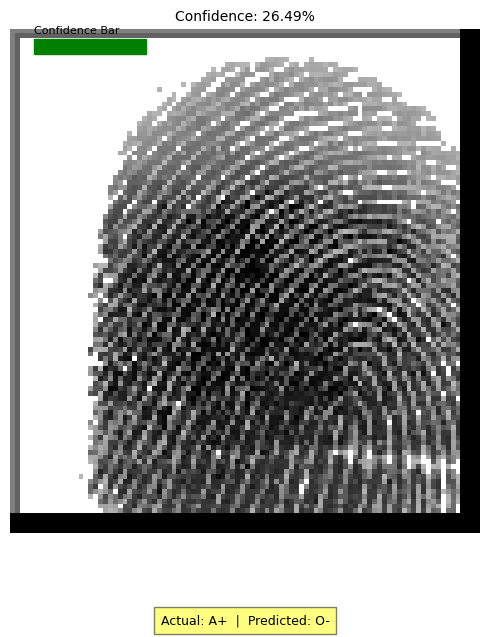

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


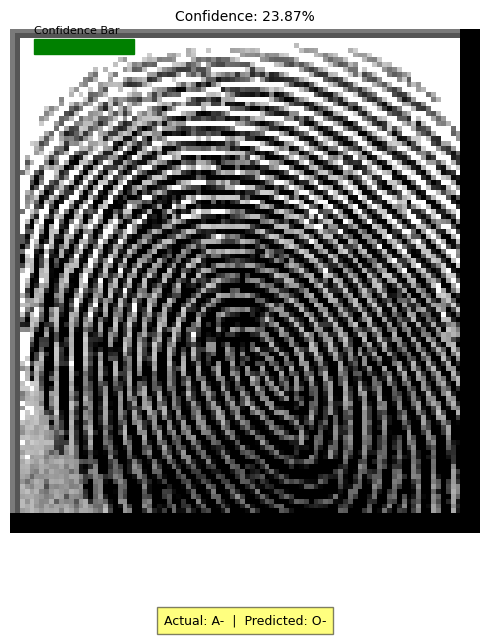

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


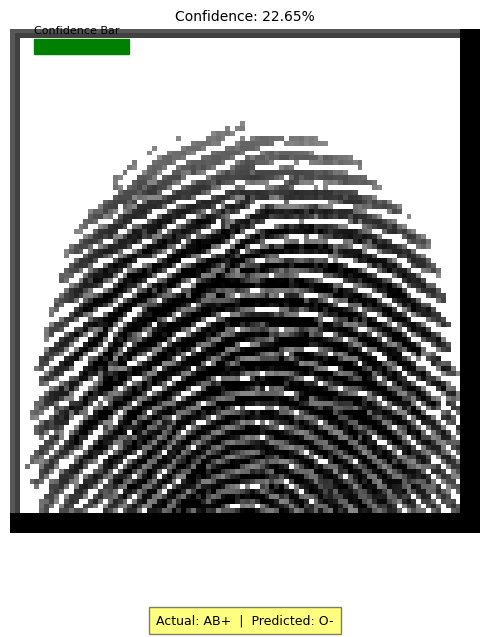

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


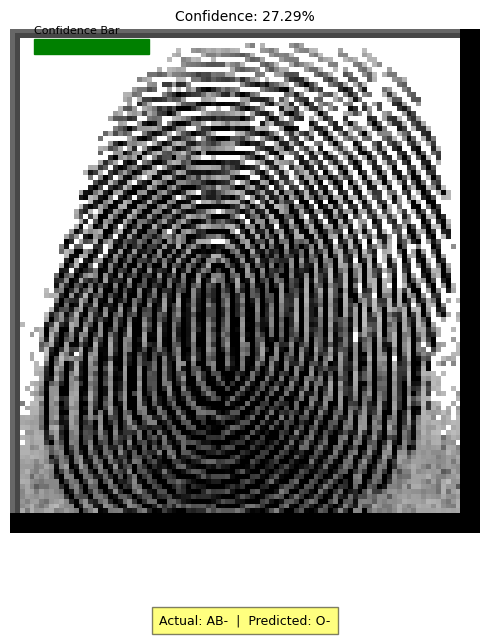

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


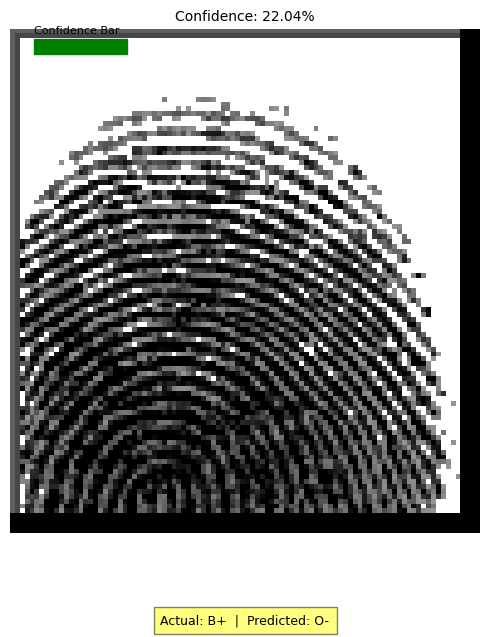

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


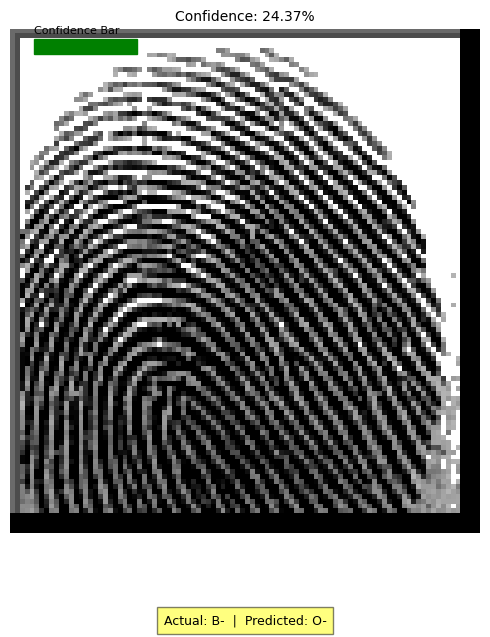

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


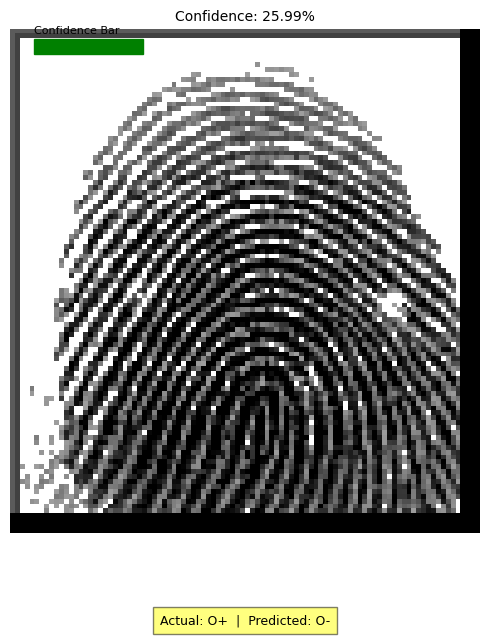

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


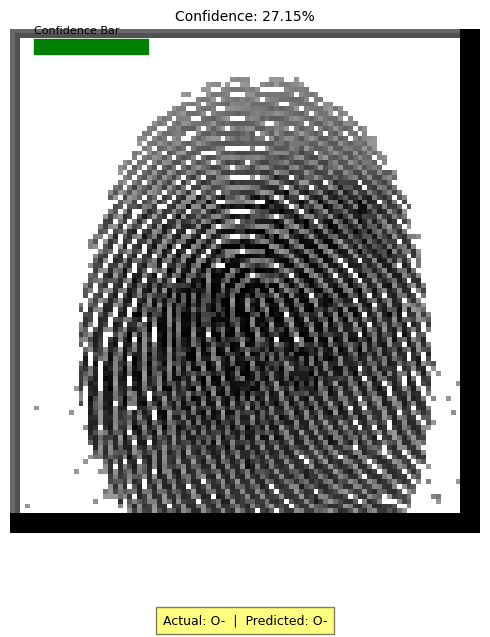

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model
from keras.preprocessing import image
from PIL import Image
import matplotlib.patches as patches

# Load your trained model
model = load_model('./Final/model.h5')

# Blood group labels (order must match model training order)
blood_groups = ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']
index_to_label = {i: label for i, label in enumerate(blood_groups)}

# Image paths (update these with your actual .bmp image paths)
image_paths = {
    'A+': 'E:\Blood Group Detection using Fingerprint\Blood_data\A+\cluster_0_1236.BMP',
    'A-': 'E:\Blood Group Detection using Fingerprint\Blood_data\A-\cluster_1_73.BMP',
    'AB+': 'E:\Blood Group Detection using Fingerprint\Blood_data\AB+\cluster_4_1495.BMP',
    'AB-': 'E:\Blood Group Detection using Fingerprint\Blood_data\AB-\cluster_5_315.BMP',
    'B+': 'E:\Blood Group Detection using Fingerprint\Blood_data\B+\cluster_2_1564.BMP',
    'B-': 'E:\Blood Group Detection using Fingerprint\Blood_data\B-\cluster_3_825.BMP',
    'O+': 'E:\Blood Group Detection using Fingerprint\Blood_data\O+\cluster_6_181.BMP',
    'O-': 'E:\Blood Group Detection using Fingerprint\Blood_data\O-\cluster_7_189.BMP'
}

# Set model image input size
img_size = (32, 32)

# Loop through each image
for actual_label, img_path in image_paths.items():
    # Load and preprocess image
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    prediction = model.predict(img_array)
    predicted_index = np.argmax(prediction)
    confidence = float(np.max(prediction)) * 100
    predicted_label = index_to_label[predicted_index]

    # Plotting the result
    fig, ax = plt.subplots(figsize=(5, 7))
    ax.imshow(image.load_img(img_path))
    ax.axis('off')

    # Title: Confidence
    plt.title(f'Confidence: {confidence:.2f}%', fontsize=10)

    # Add confidence bar
    bar_x = 0.05
    bar_y = 0.95
    ax.add_patch(patches.Rectangle((bar_x, bar_y), 0.9 * (confidence / 100), 0.03,
                                   transform=ax.transAxes, color='green'))
    ax.text(bar_x, bar_y + 0.04, 'Confidence Bar', transform=ax.transAxes, fontsize=8)

    # Bottom text
    plt.figtext(0.5, 0.01, f'Actual: {actual_label}  |  Predicted: {predicted_label}',
                wrap=True, horizontalalignment='center', fontsize=9,
                bbox={'facecolor': 'yellow', 'alpha': 0.5, 'pad': 5})

    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.utils import load_img
import matplotlib.patches as patches

# Load the model
model = load_model('./Final/model.h5', compile=False)

# Blood group labels
class_names = ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']

# Image paths – update with actual .bmp paths
image_paths = {
    'A+': 'E:\Blood Group Detection using Fingerprint\Blood_data\A+\cluster_0_1236.BMP',
    'A-': 'E:\Blood Group Detection using Fingerprint\Blood_data\A-\cluster_1_73.BMP',
    'AB+': 'E:\Blood Group Detection using Fingerprint\Blood_data\AB+\cluster_4_1495.BMP',
    'AB-': 'E:\Blood Group Detection using Fingerprint\Blood_data\AB-\cluster_5_315.BMP',
    'B+': 'E:\Blood Group Detection using Fingerprint\Blood_data\B+\cluster_2_1564.BMP',
    'B-': 'E:\Blood Group Detection using Fingerprint\Blood_data\B-\cluster_3_825.BMP',
    'O+': 'E:\Blood Group Detection using Fingerprint\Blood_data\O+\cluster_6_181.BMP',
    'O-': 'E:\Blood Group Detection using Fingerprint\Blood_data\O-\cluster_7_189.BMP'
}

# Preprocess function (same as in Flask)
def preprocess_image(file_path):
    img = load_img(file_path, target_size=(32, 32))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

# Loop through each image
for actual_label, file_path in image_paths.items():
    if not os.path.exists(file_path):
        print(f"❌ File not found: {file_path}")
        continue

    img_array = preprocess_image(file_path)

    predictions = model.predict(img_array)
    predicted_index = int(np.argmax(predictions[0]))
    predicted_label = class_names[predicted_index]
    confidence = float(np.max(predictions[0])) * 100

    # Display with matplotlib
    fig, ax = plt.subplots(figsize=(5, 7))
    img_display = load_img(file_path)
    ax.imshow(img_display)
    ax.axis('off')

    # Confidence title
    plt.title(f'Confidence: {confidence:.2f}%', fontsize=10)

    # Add visual bar
    ax.add_patch(patches.Rectangle((0.05, 0.95), 0.9 * (confidence / 100), 0.03,
                                   transform=ax.transAxes, color='green'))
    ax.text(0.05, 0.99, 'Confidence Bar', transform=ax.transAxes, fontsize=8)

    # Bottom Text
    plt.figtext(0.5, 0.01, f'Actual: {actual_label} | Predicted: {predicted_label}',
                wrap=True, horizontalalignment='center', fontsize=9,
                bbox={'facecolor': 'yellow', 'alpha': 0.5, 'pad': 5})

    plt.tight_layout()
    plt.show()
